# HRRR model output

The High-Resolution Rapid Refresh is NOAA's 3 km forecast model for the
contiguous United States, started every hour. NCEP publishes its GRIB2 output
to the anonymous `noaa-hrrr-bdp-pds` bucket on AWS, and one file holds one run
at one forecast hour: a whole CONUS grid of 170 fields in the surface set,
about 150 MB.

This walkthrough pulls the 20 UTC analysis of 6 May 2024, the afternoon
before a night of tornadoes in Oklahoma, reads surface CAPE, 0–3 km
storm-relative helicity, and the land mask out of it, and maps where the two
storm ingredients overlapped. It needs `usdata[grib]` and matplotlib; the
download is 150 MB and the run takes about ten seconds.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; xarray {xr.__version__}; numpy {np.__version__}")

Executed (UTC): 2026-09-25T16:57:25+00:00
usdata 0.27.0; xarray 2026.7.0; numpy 2.5.2


## Select

The manifest names one run and one hour. The window selects runs by
initialization time, so 20:00 to 20:00 UTC with `cycle: 20` is exactly the run
started at 20 UTC on 6 May 2024. `forecast_hour: 0` is that run's analysis:
the model's own estimate of the atmosphere at initialization, a blend of the
previous forecast with observations, rather than a projection forward.
Forecast hour 1 would be a one-hour forecast valid at 21 UTC.

`noaa:hrrr` subsets in time only. This query downloads the whole surface
file; naming GRIB2 messages with the `messages` parameter would fetch byte
ranges of it instead, as the
[HRRR guide](https://docs.usdata.dev/providers/noaa-hrrr/#fetching-selected-messages)
shows. `usdata pull dataset.yaml --dry-run` prints the size before anything
is downloaded.

In [2]:
print(manifest.read_text())

name: oklahoma-hrrr-analysis
sources:
  - dataset: noaa:hrrr
    start: 2024-05-06T20:00:00Z
    end: 2024-05-06T20:00:00Z
    params:
      cycle: 20
      forecast_hour: 0



## What arrives

One GRIB2 object from S3. The lockfile beside the manifest pins its name and
SHA-256, so a pull with the lockfile present restores exactly these bytes.
The provider notes describe no revision cycle for archived runs, so a
checksum mismatch would mean a replaced or removed object.

In [3]:
result = pull(manifest)
(item,) = result.fetched
print("File:", item.path.name)
print(f"Bytes: {item.provenance.size} ({item.provenance.size / 1e6:.1f} MB)")
print("Source:", item.provenance.source_url)
print("Retrieved (UTC):", item.provenance.retrieved_at.isoformat(timespec="seconds"))
print("Checksum:", item.provenance.checksum)
print("Valid time:", item.asset.time.start.isoformat())

File: hrrr.20240506.t20z.wrfsfcf00.grib2
Bytes: 150114757 (150.1 MB)
Source: s3://noaa-hrrr-bdp-pds/hrrr.20240506/conus/hrrr.t20z.wrfsfcf00.grib2
Retrieved (UTC): 2026-09-25T16:58:36+00:00
Checksum: sha256:0f67cd6e1edd9d0876cb1a23459e9db59c892f7345e6a74b645b663302b7655c
Valid time: 2024-05-06T20:00:00+00:00


## Open

A GRIB2 file is a stack of independent messages, one per field and level.
`item.inspect()` lists them without decoding any values; each message carries
the ecCodes keys that `open_grib2(select=...)` matches on.

In [4]:
messages = pd.DataFrame(
    message.model_dump(include={"short_name", "type_of_level", "level", "units"})
    for message in item.inspect().grib2.messages
)
print(len(messages), "messages;", (messages["short_name"] == "unknown").sum(), "named 'unknown'")
messages[messages["short_name"].isin(["cape", "hlcy", "lsm"])]

170 messages; 31 named 'unknown'


,short_name,type_of_level,level,units
104,cape,surface,0,J kg**-1
130,hlcy,heightAboveGroundLayer,3000,m**2 s**-2
131,hlcy,heightAboveGroundLayer,1000,m**2 s**-2
147,cape,pressureFromGroundLayer,18000,J kg**-1
151,cape,pressureFromGroundLayer,9000,J kg**-1
153,cape,pressureFromGroundLayer,25500,J kg**-1
157,cape,heightAboveGroundLayer,0,J kg**-1
164,lsm,surface,0,(0 - 1)


`select` matches every message that satisfies all of its keys, so three short
names crossed with two level types decode five messages: the three wanted
(surface CAPE, 0–3 km helicity, land mask) plus 0–1 km helicity and 0–3 km
layer CAPE. Because the selection spans more than one level type, every
variable is named `shortName_typeOfLevel_level`. Decoding is the slow step;
five fields take a second or two.

The grid is Lambert conformal, 1799 × 1059 points 3 km apart, so `latitude`
and `longitude` are two-dimensional coordinates, and longitudes use the 0 to
360 convention. Time is in each variable's attributes: `valid_time` is the
initialization plus the forecast hour.

In [5]:
fields = item.open_grib2(
    select={
        "shortName": ["cape", "hlcy", "lsm"],
        "typeOfLevel": ["surface", "heightAboveGroundLayer"],
    }
)
pd.DataFrame(
    {
        "variable": name,
        "long_name": variable.attrs["name"],
        "units": variable.attrs["units"],
        "valid_time": variable.attrs["valid_time"],
        "shape": str(variable.shape),
    }
    for name, variable in fields.data_vars.items()
)

,variable,long_name,units,valid_time,shape
0,cape_surface_0,Convective available potential energy,J kg-1,2024-05-06T20:00:00+00:00,"(1059, 1799)"
1,hlcy_heightAboveGroundLayer_3000,Storm relative helicity,m2 s-2,2024-05-06T20:00:00+00:00,"(1059, 1799)"
2,hlcy_heightAboveGroundLayer_1000,Storm relative helicity,m2 s-2,2024-05-06T20:00:00+00:00,"(1059, 1799)"
3,cape_heightAboveGroundLayer_0,Convective available potential energy,J kg-1,2024-05-06T20:00:00+00:00,"(1059, 1799)"
4,lsm_surface_0,Land-sea mask,(0 - 1),2024-05-06T20:00:00+00:00,"(1059, 1799)"


A value at a place means finding the nearest grid point in two dimensions,
after moving longitudes to −180 to 180. The distance here is great-circle
distance on a sphere, enough to pick a 3 km cell.

In [6]:
cape = fields["cape_surface_0"]
helicity = fields["hlcy_heightAboveGroundLayer_3000"]
latitude = fields.latitude.values
longitude = np.where(
    fields.longitude.values > 180, fields.longitude.values - 360, fields.longitude.values
)

place_lat, place_lon = 35.47, -97.52  # Oklahoma City
phi1, phi2 = np.radians(place_lat), np.radians(latitude)
dlat, dlon = phi2 - phi1, np.radians(longitude - place_lon)
haversine = np.sin(dlat / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlon / 2) ** 2
distance_km = 2 * 6371.0 * np.arcsin(np.sqrt(haversine))
y, x = np.unravel_index(distance_km.argmin(), distance_km.shape)
print(f"Nearest grid point to Oklahoma City: {latitude[y, x]:.3f} N {longitude[y, x]:.3f} E")
print(f"Distance from the city centre: {distance_km[y, x]:.1f} km")
print(f"Surface CAPE there: {float(cape[y, x]):.0f} J/kg")
print(f"0-3 km helicity there: {float(helicity[y, x]):.0f} m2/s2")

Nearest grid point to Oklahoma City: 35.477 N -97.506 E
Distance from the city centre: 1.5 km
Surface CAPE there: 3690 J/kg
0-3 km helicity there: 153 m2/s2


## A first look

Surface CAPE is the energy available to a rising parcel; 0–3 km helicity
measures the low-level wind shear a rotating storm can use. The map shades
CAPE on the model's own grid, which is already a Lambert conformal
projection, draws coastlines and lakes from the land mask, and hatches the
cells where CAPE is at least 2000 J/kg and helicity at least 200 m²/s².

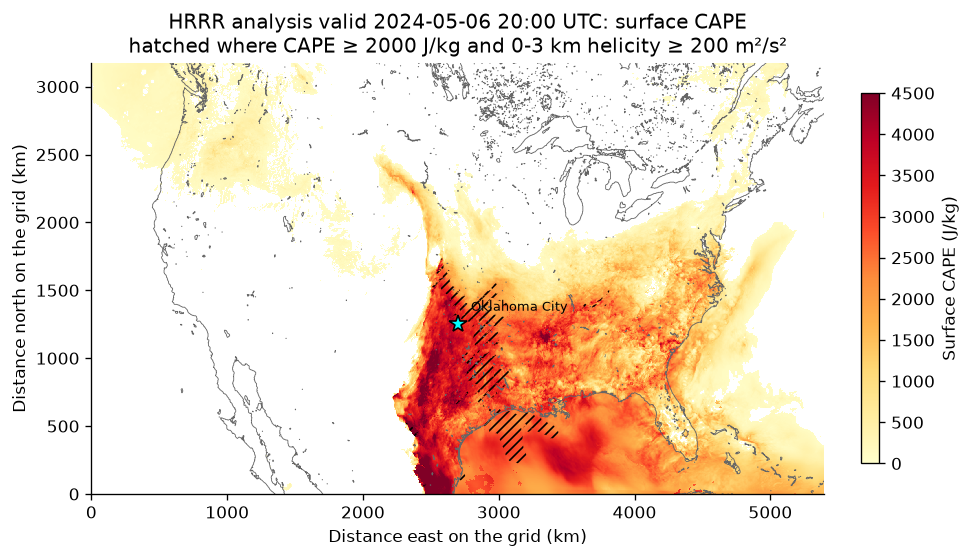

In [7]:
rows, cols = cape.shape
east_km = np.arange(cols) * 3.0
north_km = np.arange(rows)[::-1] * 3.0
overlap = (cape.values >= 2000) & (helicity.values >= 200)

fig, ax = plt.subplots(layout="constrained")
shaded = ax.imshow(
    np.ma.masked_less(cape.values, 100),
    extent=(0, cols * 3.0, 0, rows * 3.0),
    cmap="YlOrRd",
    vmin=0,
    vmax=4500,
    interpolation="nearest",
)
ax.contour(
    east_km, north_km, fields["lsm_surface_0"].values, levels=[0.5], colors="0.4", linewidths=0.5
)
ax.contourf(
    east_km, north_km, overlap.astype(float), levels=[0.5, 1.5], colors="none", hatches=["////"]
)
ax.plot(east_km[x], north_km[y], marker="*", markersize=11, color="cyan", markeredgecolor="black")
ax.annotate(
    "Oklahoma City",
    (east_km[x], north_km[y]),
    xytext=(8, 8),
    textcoords="offset points",
    fontsize=8,
)
ax.set_aspect("equal")
ax.grid(False)
ax.set(
    title=(
        "HRRR analysis valid 2024-05-06 20:00 UTC: surface CAPE\n"
        "hatched where CAPE ≥ 2000 J/kg and 0-3 km helicity ≥ 200 m²/s²"
    ),
    xlabel="Distance east on the grid (km)",
    ylabel="Distance north on the grid (km)",
)
fig.colorbar(shaded, ax=ax, label="Surface CAPE (J/kg)", shrink=0.8)
plt.show()

In [8]:
peak = np.unravel_index(int(np.nanargmax(cape.values)), cape.shape)
on_land = overlap & (fields["lsm_surface_0"].values >= 0.5)
print(f"Largest surface CAPE: {float(cape[peak]):.0f} J/kg")
print(f"  at {latitude[peak]:.2f} N {longitude[peak]:.2f} E")
print(f"Area with CAPE >= 2000 J/kg: {(cape.values >= 2000).sum() * 9:,} km2")
print(f"  and helicity >= 200 m2/s2 as well: {overlap.sum() * 9:,} km2")
print(f"  of which over land: {on_land.sum() * 9:,} km2")
near = on_land & (distance_km <= 300)
print(f"  of which within 300 km of Oklahoma City: {near.sum() * 9:,} km2")

Largest surface CAPE: 6420 J/kg
  at 28.58 N -101.11 E
Area with CAPE >= 2000 J/kg: 2,300,724 km2
  and helicity >= 200 m2/s2 as well: 271,188 km2
  of which over land: 171,360 km2
  of which within 300 km of Oklahoma City: 73,449 km2


Unstable air covered the southern and central United States east of a sharp
western edge, the dryline, and the largest value in the domain sat just south
of the Rio Grande in Mexico. Strong low-level shear overlapped it in a band
along and east of that edge, from Kansas through Oklahoma into east Texas, and
over the Gulf of Mexico. White areas hold less than 100 J/kg.

This is the afternoon environment, 8 hours 39 minutes before a tornado report
in Oklahoma County at 04:39 UTC on 7 May, not the air that storm formed in;
the run valid then is `cycle: 4`, `forecast_hour: 0` on 7 May, a separate
150 MB file. CAPE and helicity are ingredients, not a tornado forecast, and
each value is one 3 km cell of one model run.

The [severe-weather case study](https://usdata.dev/studies/severe-weather-case-study/)
reads that 04 UTC analysis for the same report, as two fields fetched by byte
range, beside radar, lightning, and the report archives.

## Pin and cite

`verify` checks the cached file against the lockfile's checksum. Keep the
manifest, lockfile, and cached bytes together; public cloud retention is not
a promise.

In [9]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

noaa:hrrr
  NOAA High-Resolution Rapid Refresh (HRRR) Model was accessed on 2026-09-16 from https://registry.opendata.aws/noaa-hrrr-pds
  homepage: https://registry.opendata.aws/noaa-hrrr-pds/
  license: US Government Work (public domain)
  terms: https://www.noaa.gov/information-technology/open-data-dissemination
  retrieved: 2026-09-16; 1 checksummed asset (150,114,757 bytes) pinned by usdata 0.18.0
  sources: 1


## What was awkward

- `select` crosses its keys: three short names and two level types decode
  five messages, and the two unwanted ones cost decode time and memory. Asking
  for exactly three fields that sit on different level types takes three
  `open` calls or a cross product like this one.
- Units used to arrive as raw ecCodes strings, `J kg**-1` and `m**2 s**-2`, with
  no documented canonical form to translate to. `units` now takes the UDUNITS
  notation CF uses, `J kg-1` and `m2 s-2`, with the file's spelling kept in
  `GRIB_units`; prettier plot labels are still written by hand.
- 31 of the 170 messages have the short name `unknown`, from HRRR's local
  parameter tables, and some `(shortName, typeOfLevel, level)` triples repeat.
  Those messages cannot be told apart by the keys the inventory shows; the
  guide says to select them by discipline, category, and parameter number.
- Finding the grid point nearest a place is left to the caller, and every
  model walkthrough repeats the same few lines of NumPy, including undoing the
  0 to 360 longitude convention first.
- The projection arrives as raw ecCodes keys on `Dataset.attrs`
  (`LaDInDegrees`, `Latin1InDegrees`, `DxInMetres`, `shapeOfTheEarth`) with no
  CRS object, so drawing state borders or working in projected coordinates
  starts by rebuilding the projection from those keys. The map above plots
  the grid itself for that reason.
- The retrieval URL is `item.provenance.source_url` while the asset's is
  `item.asset.href`: two names for the same idea on two objects usually used
  together.
- The two dates in this notebook disagree. A pull that restores from the
  committed lockfile downloads the object again, so `retrieved_at` above is
  the day this notebook ran, while the citation says the file was accessed on
  the day the lockfile was first written. The citation is the one to quote,
  but nothing on the fetched item says so.
- The `grib` extra installs with pip alone on Linux, and on Windows through
  Python 3.13; macOS needs the ecCodes library from conda-forge or Homebrew
  first. The [reader reference](https://docs.usdata.dev/reference/readers/)
  has the details.